In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from src.config import (
    TRAIN_PATH,
    TEST_PATH,
    SAMPLE_SUBMISSION_PATH,
    SUBMISSION_DIR,
    TARGET,
    ID_COL,
    RANDOM_STATE,
    N_SPLITS
)

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


In [3]:
X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (56000, 23)
y shape: (56000,)
X_test shape: (24000, 23)


In [4]:
test_ids = X_test[ID_COL]

X = X.drop(columns=[ID_COL])
X_test = X_test.drop(columns=[ID_COL])

print("X shape after dropping id:", X.shape)
print("X_test shape after dropping id:", X_test.shape)

X shape after dropping id: (56000, 22)
X_test shape after dropping id: (24000, 22)


In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric feature count: 15
Categorical feature count: 7

Numeric features:
['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']

Categorical features:
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [7]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [8]:
models = {
    "ridge": Ridge(alpha=10.0),

    "random_forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

In [9]:
results = []

for model_name, model in models.items():
    print(f"Training: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = -cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    results.append({
        "model": model_name,
        "cv_rmse_mean": scores.mean(),
        "cv_rmse_std": scores.std(),
        "fold_scores": scores
    })

    print(f"{model_name} RMSE: {scores.mean():.5f} ± {scores.std():.5f}")
    print("-" * 60)

Training: ridge
ridge RMSE: 1.25640 ± 0.01147
------------------------------------------------------------
Training: random_forest
random_forest RMSE: 1.29630 ± 0.01098
------------------------------------------------------------
Training: extra_trees
extra_trees RMSE: 1.29328 ± 0.01004
------------------------------------------------------------
Training: gradient_boosting
gradient_boosting RMSE: 1.23808 ± 0.00941
------------------------------------------------------------


In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("cv_rmse_mean").reset_index(drop=True)

results_df[["model", "cv_rmse_mean", "cv_rmse_std"]]

,model,cv_rmse_mean,cv_rmse_std
0,gradient_boosting,1.238085,0.009412
1,ridge,1.256401,0.011473
2,extra_trees,1.293276,0.010036
3,random_forest,1.296299,0.010980


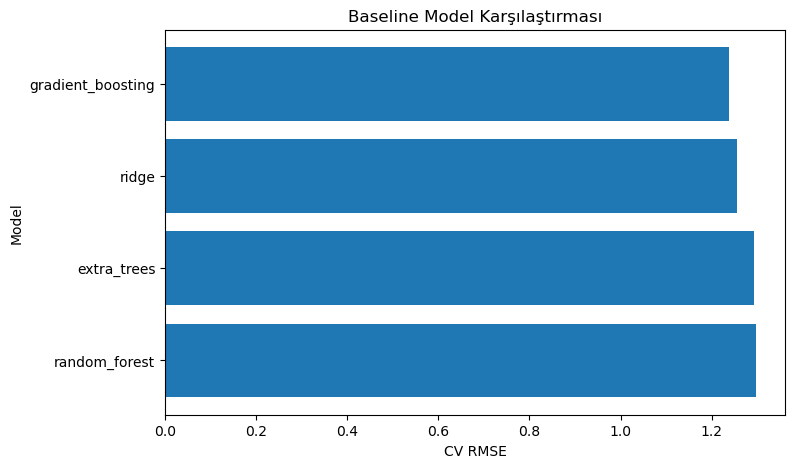

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["cv_rmse_mean"])
plt.xlabel("CV RMSE")
plt.ylabel("Model")
plt.title("Baseline Model Karşılaştırması")
plt.gca().invert_yaxis()
plt.show()

In [12]:
best_model_name = results_df.loc[0, "model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: gradient_boosting


In [13]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
test_preds = final_pipeline.predict(X_test)

print("Prediction min:", test_preds.min())
print("Prediction max:", test_preds.max())
print("Prediction mean:", test_preds.mean())

Prediction min: -0.4965986918352516
Prediction max: 10.592406352881888
Prediction mean: 5.938633687540974


In [15]:
test_preds = np.clip(test_preds, 0, 10)

print("Clipped prediction min:", test_preds.min())
print("Clipped prediction max:", test_preds.max())
print("Clipped prediction mean:", test_preds.mean())

Clipped prediction min: 0.0
Clipped prediction max: 10.0
Clipped prediction mean: 5.938356604837281


In [16]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: test_preds
})

submission.head()

,id,bilissel_performans_skoru
0,1,5.751474
1,2,6.200918
2,3,3.139865
3,4,6.893776
4,5,3.756625


In [17]:
print("Submission shape:", submission.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nSubmission columns:")
print(submission.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

Submission shape: (24000, 2)
Sample submission shape: (2, 2)

Submission columns:
['id', 'bilissel_performans_skoru']

Sample submission columns:
['id', 'bilissel_performans_skoru']


In [18]:
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

submission_path = SUBMISSION_DIR / f"submission_baseline_{best_model_name}.csv"

submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)

Saved submission to: C:\Users\pc\Desktop\yzta-2026-datathon\submissions\submission_baseline_gradient_boosting.csv


In [19]:
check_submission = pd.read_csv(submission_path)

check_submission.head()

,id,bilissel_performans_skoru
0,1,5.751474
1,2,6.200918
2,3,3.139865
3,4,6.893776
4,5,3.756625


In [20]:
check_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         24000 non-null  int64  
 1   bilissel_performans_skoru  24000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 375.1 KB


In [21]:
results_df[["model", "cv_rmse_mean", "cv_rmse_std"]]

,model,cv_rmse_mean,cv_rmse_std
0,gradient_boosting,1.238085,0.009412
1,ridge,1.256401,0.011473
2,extra_trees,1.293276,0.010036
3,random_forest,1.296299,0.010980
